# 03 — Feature Selection : Lasso, SHAP, Boruta

**Objectif** : Réduire 377 features → ~100-200 features pertinentes for FR et UK.

**3 méthodes complémentaires** :
1. **Lasso (L1)** — Filtre linéaire. Shrink les coefficients inusefuls à 0. Rapide but ne capture pas les non-linéarités.
2. **SHAP (TreeExplainer)** — Importance non-linéaire via un LightGBM rapide. Meone la contribution réelle de chaque feature.
3. **Boruta** — Test statistique : compare chaque feature à des copies "shadow" aléatoires. Si une feature ne bat pas le bruit, elle est rejetée.

**Consensus** : features retenues par ≥2 méthodes on 3.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_data, merge_train
from src.feature_engineering import build_features
from src.validation import create_holdout_split, split_X_y
from src.feature_selection import lasso_selection, shap_selection

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

In [2]:
# Load and prepare data
x_train, y_train, x_test = load_data(data_dir='../data/raw')
train = merge_train(x_train, y_train)
df = build_features(train, config)
train_df, val_df = create_holdout_split(df, config)

# Split for FR
X_tr_fr, y_tr_fr = split_X_y(train_df, 'fr_spot')
X_val_fr, y_val_fr = split_X_y(val_df, 'fr_spot')

# Split for UK
X_tr_uk, y_tr_uk = split_X_y(train_df, 'uk_spot')
X_val_uk, y_val_uk = split_X_y(val_df, 'uk_spot')

print(f"Features: {X_tr_fr.shape[1]}")
print(f"Train: {len(X_tr_fr):,} rows | Val: {len(X_val_fr):,} rows")

Holdout split @ 2024-02-01
  Train: 13,921 rows  (2022-07-01 → 2024-01-31)
  Val:   3,623 rows  (2024-02-01 → 2024-06-30)
Features: 377
Train: 13,921 rows | Val: 3,623 rows


---
## 1. Lasso (L1 Regularization)

Le Lasso résout : `min ||y - Xβ||² + α||β||₁`

Le terme L1 (`α||β||₁`) force les coefficients inusefuls exactement à **zéro**. Plus α est grand, plus de features sont éliminées. LassoCV choisit α automatiquement par cross-validation (TimeSeriesSplit, 3 folds).

**Limites** : ne capture que les relations linéaires. Une feature with un effet quadratique (ex: `scarcity_ratio > 0.85` → prix explosent) peut être ignorée.

In [3]:
# Run Lasso for FR and UK
print("=== LASSO — FR ===")
lasso_fr = lasso_selection(X_tr_fr, y_tr_fr, top_n=150)

print("\n=== LASSO — UK ===")
lasso_uk = lasso_selection(X_tr_uk, y_tr_uk, top_n=150)

print(f"\nFR: {len(lasso_fr)} features | UK: {len(lasso_uk)} features")
print(f"Common: {len(set(lasso_fr) & set(lasso_uk))} features")

=== LASSO — FR ===
  LassoCV alpha: 2.4421
  Lasso: 36 non-zero / 377 total → keeping top 36

=== LASSO — UK ===
  LassoCV alpha: 6.2506
  Lasso: 19 non-zero / 377 total → keeping top 19

FR: 36 features | UK: 19 features
Common: 11 features


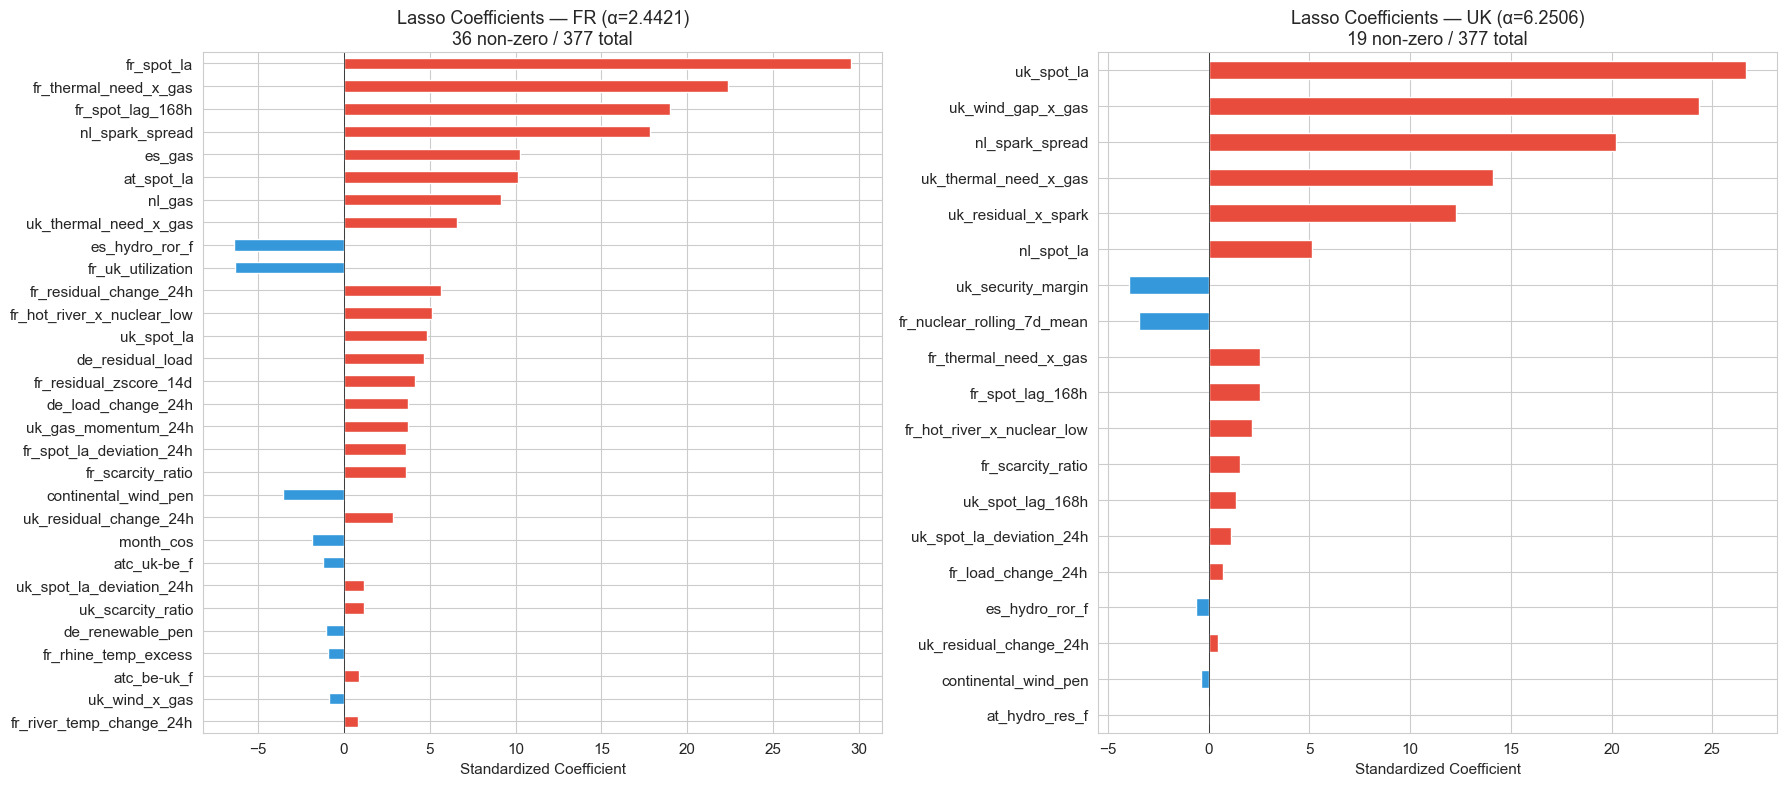

Rouge = positif (feature ↑ → prix ↑), Bleu = négatif (feature ↑ → prix ↓)


In [4]:
# Lasso coefficients visualization
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, target, X_tr, y_tr, label in [
    (axes[0], 'fr_spot', X_tr_fr, y_tr_fr, 'FR'),
    (axes[1], 'uk_spot', X_tr_uk, y_tr_uk, 'UK'),
]:
    X_num = X_tr.select_dtypes(include='number')
    scaler = StandardScaler()
    X_filled = X_num.fillna(X_num.median())
    X_scaled = scaler.fit_transform(X_filled)
    
    tscv = TimeSeriesSplit(n_splits=3)
    model = LassoCV(alphas=np.logspace(-4, 1, 50), cv=tscv, max_iter=5000, n_jobs=-1)
    model.fit(X_scaled, y_tr)
    
    coefs = pd.Series(model.coef_, index=X_num.columns)
    nonzero = coefs[coefs.abs() > 0].sort_values(key=abs, ascending=True)
    
    # Plot top 30
    top30 = nonzero.tail(30)
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top30.values]
    top30.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Lasso Coefficients — {label} (α={model.alpha_:.4f})\n'
                 f'{len(nonzero)} non-zero / {len(X_num.columns)} total', fontsize=13)
    ax.set_xlabel('Standardized Coefficient')
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../outputs/lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rouge = positif (feature ↑ → prix ↑), Bleu = négatif (feature ↑ → prix ↓)")

### Interprétation Lasso

Le Lasso est **très sélectif** (~30-40 features). C'est normal :
- Parmi des features colinéaires (ex: `fr_spark_spread`, `fr_spark_ocgt`, `fr_spark_ccgt`), Lasso n'en garde qu'une
- Les effets non-linéaires (seuils, interactions) ne sont pas capturés
- C'est un **lower bound** : si Lasso garde une feature, elle est certainement useful. Mais il en manque.

---
## 2. SHAP (SHapley Additive exPlanations)

SHAP meone la **contribution marginale** de chaque feature à chaque prédiction, basé on la théorie des jeux (valeurs de Shapley). On utilise TreeExplainer on un LightGBM rapide (500 arbres).

**Avantages** :
- Capture les non-linéarités et interactions
- Chaque prédiction a ses propres valeurs SHAP → on peut voir **quand** et **comment** une feature agit
- mean(|SHAP|) = importance globale fidèle

In [5]:
import shap
import lightgbm as lgb

# Train quick LightGBM for SHAP — FR
model_fr = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=5,
    min_child_samples=20, verbose=-1, n_jobs=-1
)
model_fr.fit(X_tr_fr, y_tr_fr, eval_set=[(X_val_fr, y_val_fr)],
             callbacks=[lgb.early_stopping(50, verbose=False)])

# SHAP values
explainer_fr = shap.TreeExplainer(model_fr)
shap_values_fr = explainer_fr.shap_values(X_val_fr)
shap_imp_fr = pd.Series(np.abs(shap_values_fr).mean(axis=0), index=X_tr_fr.columns).sort_values(ascending=False)

print(f"LightGBM FR: {model_fr.best_iteration_} iterations")
print(f"Val RMSE: {np.sqrt(np.mean((y_val_fr - model_fr.predict(X_val_fr))**2)):.2f}")

LightGBM FR: 344 iterations
Val RMSE: 30.42


In [6]:
# Train quick LightGBM for SHAP — UK
model_uk = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=5,
    min_child_samples=20, verbose=-1, n_jobs=-1
)
model_uk.fit(X_tr_uk, y_tr_uk, eval_set=[(X_val_uk, y_val_uk)],
             callbacks=[lgb.early_stopping(50, verbose=False)])

explainer_uk = shap.TreeExplainer(model_uk)
shap_values_uk = explainer_uk.shap_values(X_val_uk)
shap_imp_uk = pd.Series(np.abs(shap_values_uk).mean(axis=0), index=X_tr_uk.columns).sort_values(ascending=False)

print(f"LightGBM UK: {model_uk.best_iteration_} iterations")
print(f"Val RMSE: {np.sqrt(np.mean((y_val_uk - model_uk.predict(X_val_uk))**2)):.2f}")

LightGBM UK: 498 iterations
Val RMSE: 12.28


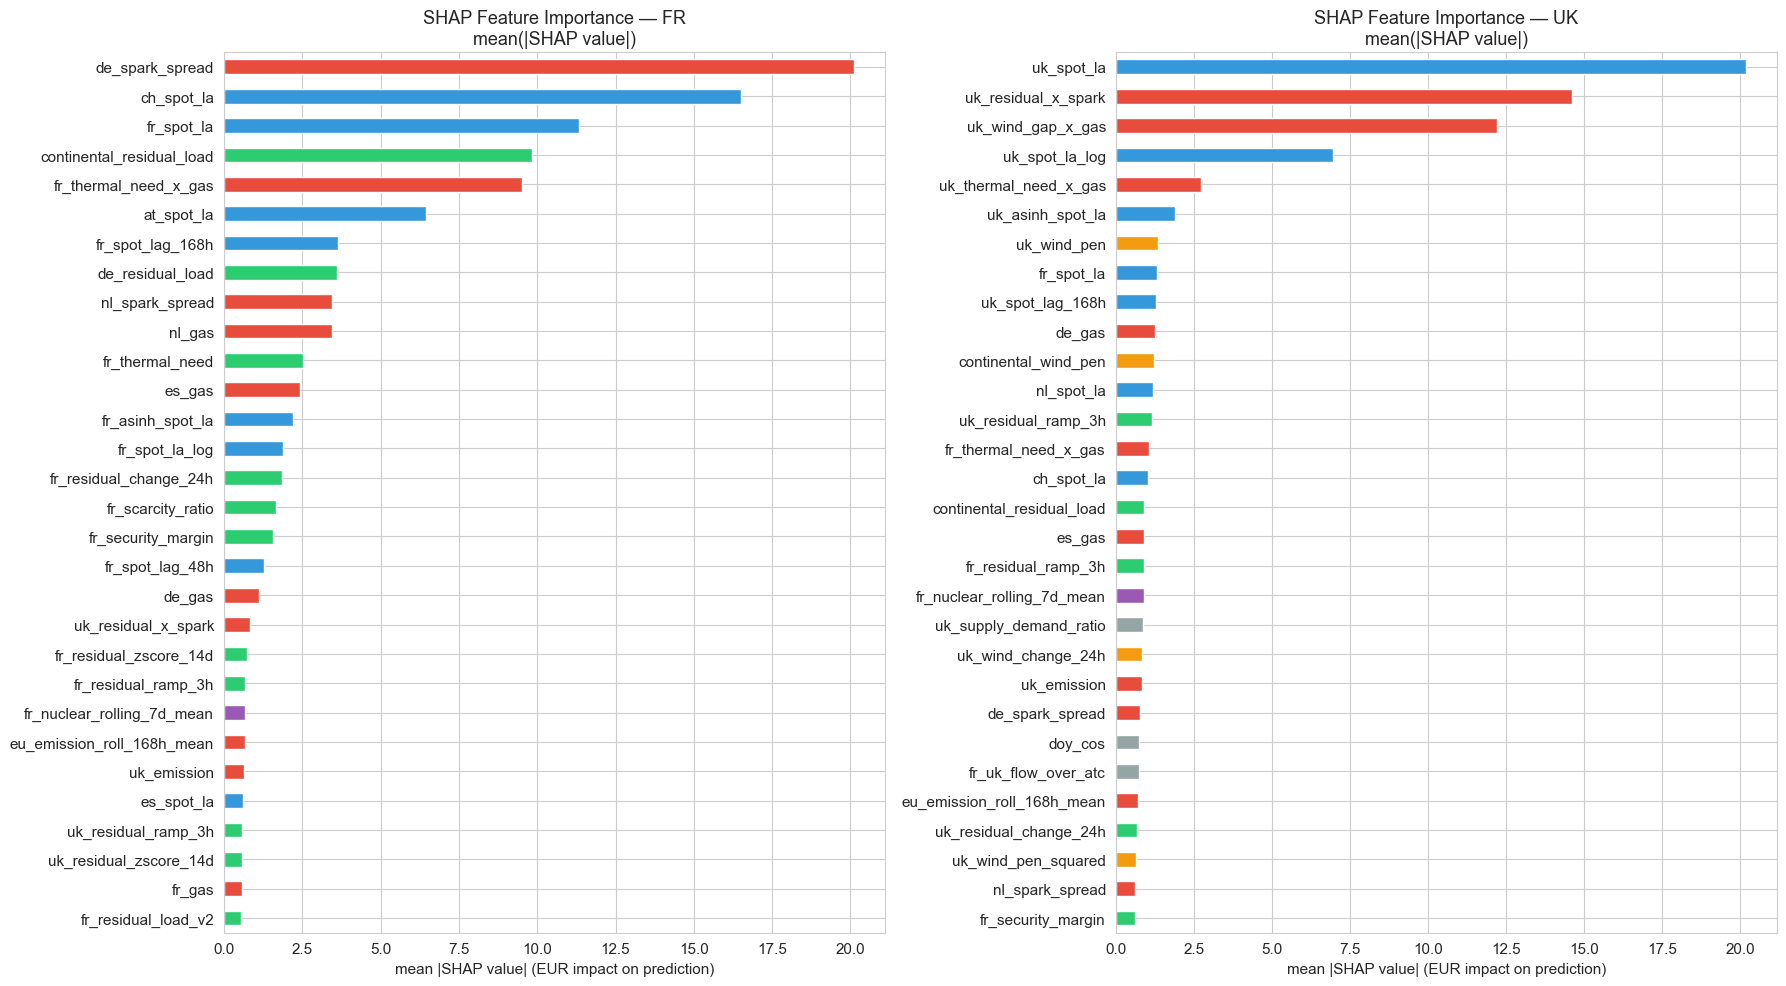

Rouge=Coûts/Gas | Bleu=Prix lags | Vert=Supply/Demand | Orange=ENR | Violet=Nucléaire | Turquoise=Transforms


In [7]:
# SHAP Bar Plot — Top 30 features
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, imp, label in [(axes[0], shap_imp_fr, 'FR'), (axes[1], shap_imp_uk, 'UK')]:
    top30 = imp.head(30).iloc[::-1]  # reverse for horizontal bar
    
    # Color by category
    def get_category_color(feat):
        if 'spark' in feat or 'gas' in feat or 'emission' in feat: return '#e74c3c'  # Cost/Gas
        if 'spot_la' in feat or 'lag' in feat or 'continental_avg' in feat: return '#3498db'  # Price lags
        if 'residual' in feat or 'thermal' in feat or 'scarcity' in feat or 'security' in feat: return '#2ecc71'  # Supply/Demand
        if 'wind' in feat or 'solar' in feat or 'renewable' in feat: return '#f39c12'  # Renewables
        if 'nuclear' in feat: return '#9b59b6'  # Nuclear
        if 'jump' in feat or 'vol_ratio' in feat or 'mean_rev' in feat or 'zscore' in feat: return '#e67e22'  # SDE/Anomaly
        if 'asinh' in feat or 'log' in feat: return '#1abc9c'  # Transforms
        return '#95a5a6'  # Other
    
    colors = [get_category_color(f) for f in top30.index]
    top30.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'SHAP Feature Importance — {label}\nmean(|SHAP value|)', fontsize=13)
    ax.set_xlabel('mean |SHAP value| (EUR impact on prediction)')

plt.tight_layout()
plt.savefig('../outputs/shap_importance_top30.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rouge=Coûts/Gas | Bleu=Prix lags | Vert=Supply/Demand | Orange=ENR | Violet=Nucléaire | Turquoise=Transforms")

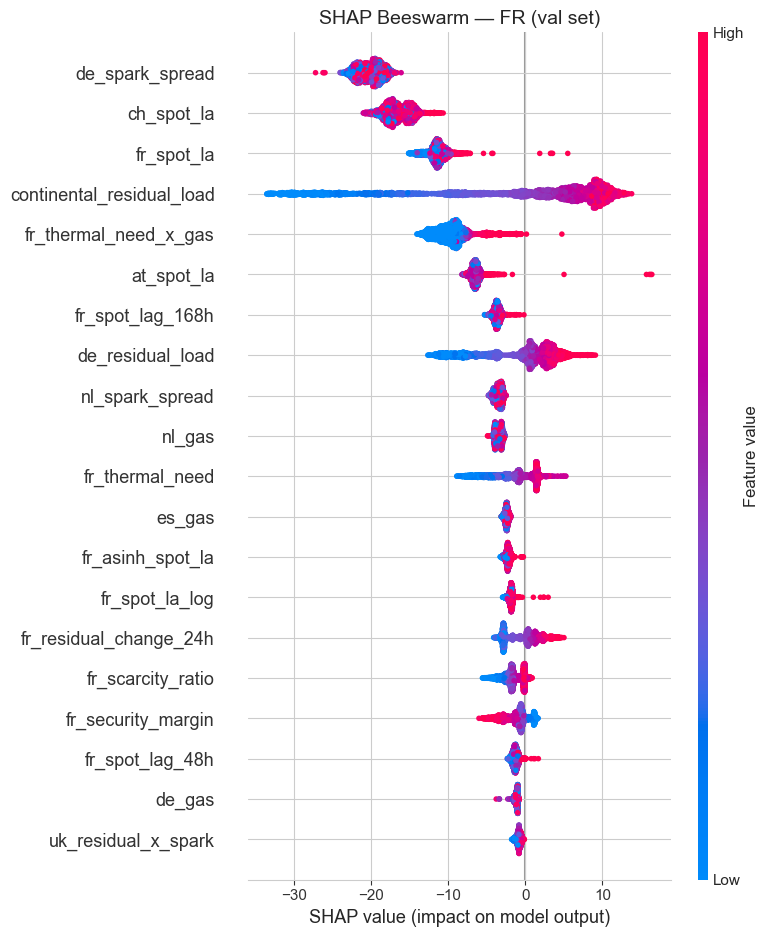

Chaque point = 1 heure du val set
Rouge = valeur haute de la feature, Bleu = valeur basse
Position X = impact sur la prédiction (EUR)


In [8]:
# SHAP Beeswarm plot — FR (top 20)
# Shows HOW each feature impacts predictions (direction + magnitude)
fig, ax = plt.subplots(figsize=(14, 10))
shap.summary_plot(shap_values_fr, X_val_fr, max_display=20, show=False)
plt.title('SHAP Beeswarm — FR (val set)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm_fr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chaque point = 1 heure du val set")
print("Rouge = valeur haute de la feature, Bleu = valeur basse")
print("Position X = impact sur la prédiction (EUR)")

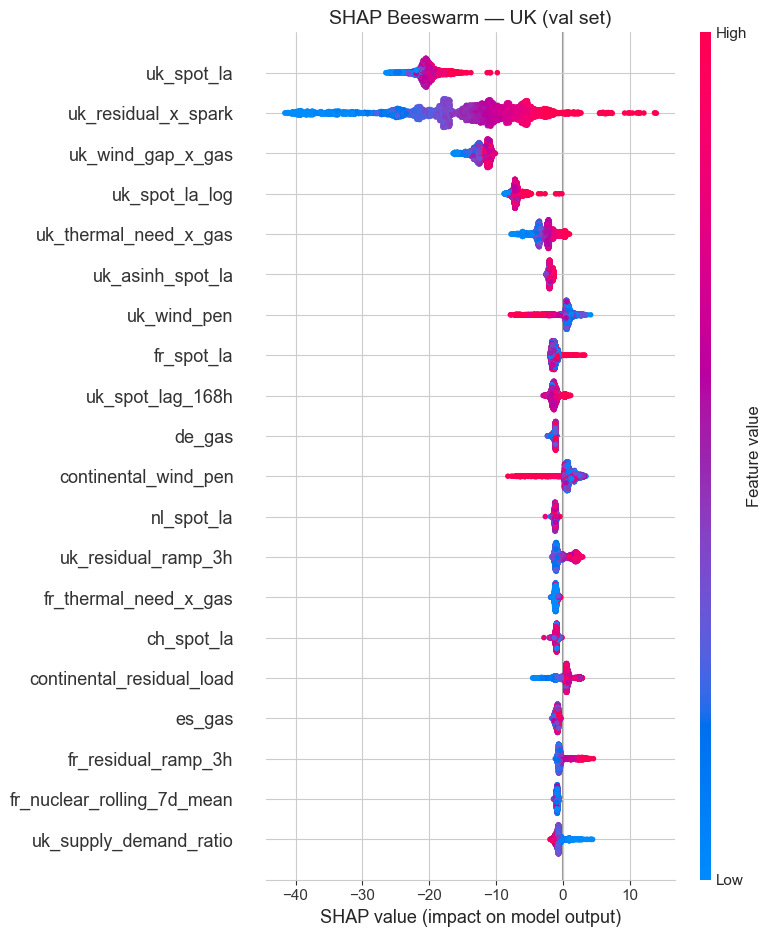

In [9]:
# SHAP Beeswarm plot — UK (top 20)
fig, ax = plt.subplots(figsize=(14, 10))
shap.summary_plot(shap_values_uk, X_val_uk, max_display=20, show=False)
plt.title('SHAP Beeswarm — UK (val set)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm_uk.png', dpi=150, bbox_inches='tight')
plt.show()

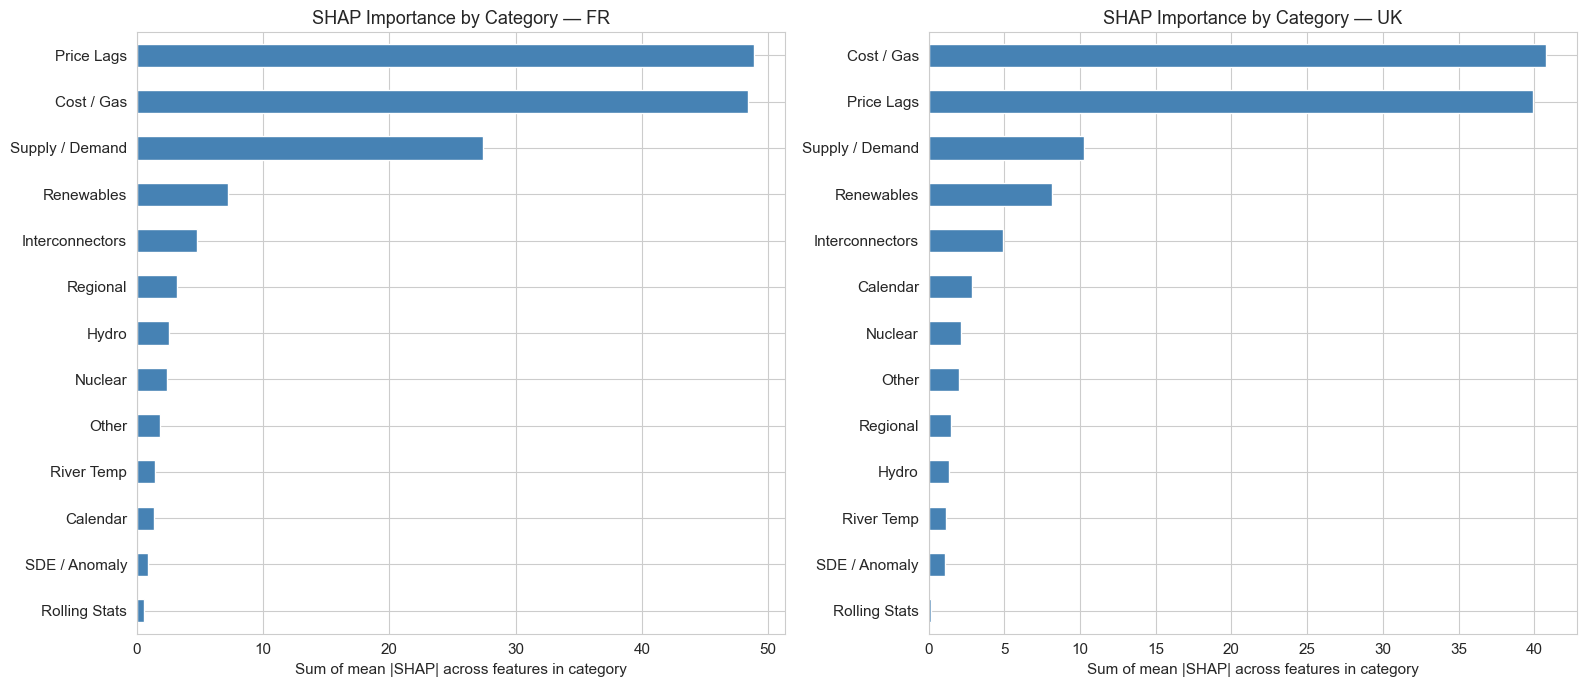

In [10]:
# SHAP importance by category — What TYPES of features matter most?
def categorize_feature(feat):
    if any(x in feat for x in ['spark', 'gas', 'emission', 'ocgt', 'ccgt']): return 'Cost / Gas'
    if any(x in feat for x in ['spot_la', 'lag', 'continental_avg', 'spot_change', 'ewm', 'deviation', 'asinh_spot', 'spot_la_log']): return 'Price Lags'
    if any(x in feat for x in ['residual', 'thermal', 'scarcity', 'security', 'baseload', 'supply_demand', 'dispatchable']): return 'Supply / Demand'
    if any(x in feat for x in ['wind', 'solar', 'renewable']): return 'Renewables'
    if 'nuclear' in feat: return 'Nuclear'
    if any(x in feat for x in ['hour', 'dow', 'month', 'weekend', 'business', 'holiday', 'night', 'peak', 'ramp_1h', 'ramp_3h', 'quarter', 'week_of']): return 'Calendar'
    if any(x in feat for x in ['atc', 'ntc', 'flow', 'utilization', 'congested', 'unused', 'import', 'cost_fr', 'cost_uk']): return 'Interconnectors'
    if any(x in feat for x in ['river', 'rhone', 'rhine', 'danube']): return 'River Temp'
    if any(x in feat for x in ['jump', 'vol_ratio', 'mean_rev', 'zscore', 'acceleration', 'momentum']): return 'SDE / Anomaly'
    if any(x in feat for x in ['hydro', 'alpine', 'biomass']): return 'Hydro'
    if any(x in feat for x in ['roll_', 'volatility']): return 'Rolling Stats'
    if any(x in feat for x in ['squared', 'cubed', 'sqrt', 'clipped', 'log', 'asinh']): return 'Transforms'
    if any(x in feat for x in ['load_f', 'load_change', 'load_roll', 'continental_load', 'iberian', 'nordic', 'be_nl', 'at_ch']): return 'Regional'
    return 'Other'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, imp, label in [(axes[0], shap_imp_fr, 'FR'), (axes[1], shap_imp_uk, 'UK')]:
    cat_imp = pd.Series({feat: imp[feat] for feat in imp.index}).groupby(imp.index.map(categorize_feature)).sum()
    cat_imp = cat_imp.sort_values(ascending=True)
    
    cat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'SHAP Importance by Category — {label}', fontsize=13)
    ax.set_xlabel('Sum of mean |SHAP| across features in category')

plt.tight_layout()
plt.savefig('../outputs/shap_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

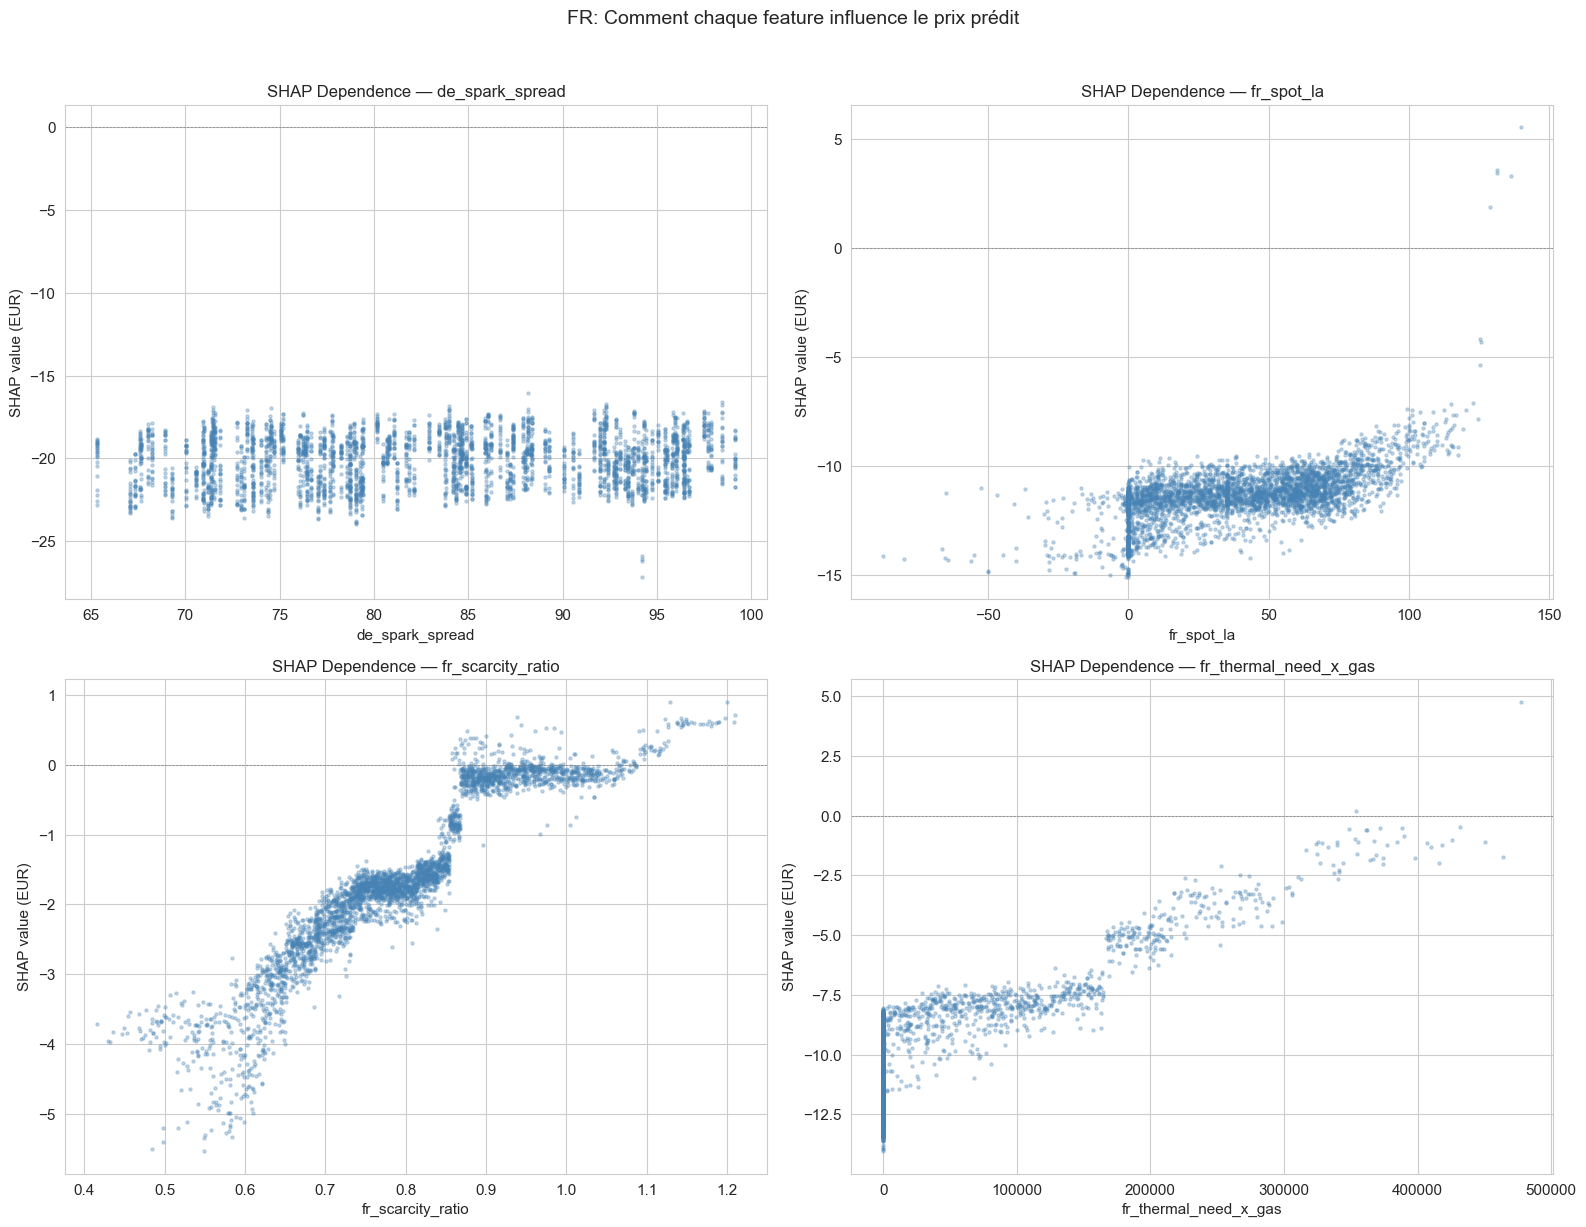

Chaque point = 1 heure. X = valeur de la feature, Y = impact SHAP (EUR)
Si la relation n'est pas linéaire → le modèle capture des effets de seuil


In [11]:
# SHAP Dependence Plots — Key features
# Shows the non-linear relationship between feature value and SHAP value
key_features_fr = ['de_spark_spread', 'fr_spot_la', 'fr_scarcity_ratio', 'fr_thermal_need_x_gas']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.flat, key_features_fr):
    idx = list(X_val_fr.columns).index(feat)
    ax.scatter(X_val_fr[feat].values, shap_values_fr[:, idx], 
               alpha=0.3, s=5, c='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value (EUR)')
    ax.set_title(f'SHAP Dependence — {feat}', fontsize=12)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('FR: Comment chaque feature influence le prix prédit', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_dependence_fr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chaque point = 1 heure. X = valeur de la feature, Y = impact SHAP (EUR)")
print("Si la relation n'est pas linéaire → le modèle capture des effets de seuil")

In [12]:
# SHAP tables — Full ranking FR and UK
print("=" * 80)
print("TOP 50 SHAP FEATURES — FR")
print("=" * 80)
for i, (feat, val) in enumerate(shap_imp_fr.head(50).items()):
    cat = categorize_feature(feat)
    in_lasso = '✓' if feat in lasso_fr else ' '
    print(f"  {i+1:3d}. {feat:45s} SHAP={val:7.2f}  Lasso={in_lasso}  [{cat}]")

print(f"\n{'=' * 80}")
print("TOP 50 SHAP FEATURES — UK")
print("=" * 80)
for i, (feat, val) in enumerate(shap_imp_uk.head(50).items()):
    cat = categorize_feature(feat)
    in_lasso = '✓' if feat in lasso_uk else ' '
    print(f"  {i+1:3d}. {feat:45s} SHAP={val:7.2f}  Lasso={in_lasso}  [{cat}]")

TOP 50 SHAP FEATURES — FR
    1. de_spark_spread                               SHAP=  20.11  Lasso=   [Cost / Gas]
    2. ch_spot_la                                    SHAP=  16.52  Lasso=   [Price Lags]
    3. fr_spot_la                                    SHAP=  11.32  Lasso=✓  [Price Lags]
    4. continental_residual_load                     SHAP=   9.82  Lasso=   [Supply / Demand]
    5. fr_thermal_need_x_gas                         SHAP=   9.52  Lasso=✓  [Cost / Gas]
    6. at_spot_la                                    SHAP=   6.46  Lasso=✓  [Price Lags]
    7. fr_spot_lag_168h                              SHAP=   3.65  Lasso=✓  [Price Lags]
    8. de_residual_load                              SHAP=   3.60  Lasso=✓  [Supply / Demand]
    9. nl_spark_spread                               SHAP=   3.45  Lasso=✓  [Cost / Gas]
   10. nl_gas                                        SHAP=   3.44  Lasso=✓  [Cost / Gas]
   11. fr_thermal_need                               SHAP=   2.54  Lasso= 

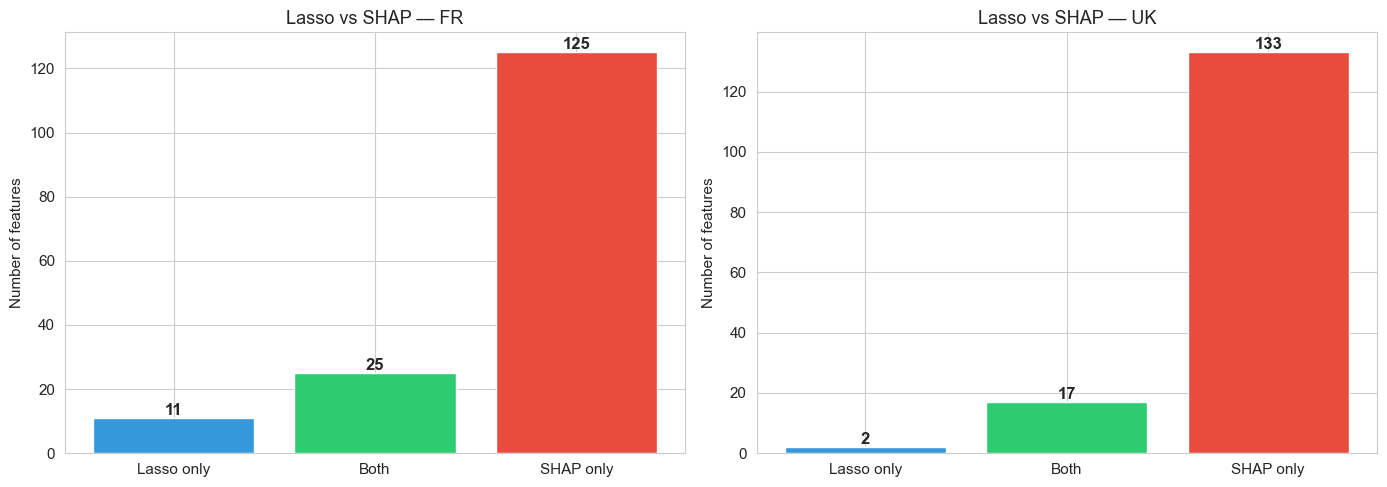

'Both' = features validées par les 2 méthodes → haute confiance


In [13]:
# Venn diagram: Lasso vs SHAP overlap
lasso_fr_set = set(lasso_fr)
lasso_uk_set = set(lasso_uk)
shap_fr_set = set(shap_imp_fr.head(150).index)
shap_uk_set = set(shap_imp_uk.head(150).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lasso_set, shap_set, label in [
    (axes[0], lasso_fr_set, shap_fr_set, 'FR'),
    (axes[1], lasso_uk_set, shap_uk_set, 'UK'),
]:
    only_lasso = len(lasso_set - shap_set)
    only_shap = len(shap_set - lasso_set)
    both = len(lasso_set & shap_set)
    
    data = [only_lasso, both, only_shap]
    labels_bar = ['Lasso only', 'Both', 'SHAP only']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    bars = ax.bar(labels_bar, data, color=colors)
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=12, fontweight='bold')
    
    ax.set_title(f'Lasso vs SHAP — {label}', fontsize=13)
    ax.set_ylabel('Number of features')

plt.tight_layout()
plt.savefig('../outputs/lasso_vs_shap_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("'Both' = features validées par les 2 méthodes → haute confiance")

In [14]:
# New features (cat 17-23) performance check
new_features = [
    'fr_residual_load_v2', 'fr_security_margin', 'uk_security_margin',
    'fr_scarcity_ratio', 'uk_scarcity_ratio',
    'fr_scarcity_critical', 'uk_scarcity_critical',
    'fr_scarcity_extreme', 'uk_scarcity_extreme',
    'fr_load_ramp_1h', 'fr_load_ramp_3h', 'uk_load_ramp_1h', 'uk_load_ramp_3h',
    'fr_residual_ramp_1h', 'fr_residual_ramp_3h', 'uk_residual_ramp_1h', 'uk_residual_ramp_3h',
    'fr_spark_ocgt', 'uk_spark_ocgt', 'fr_spark_ccgt', 'uk_spark_ccgt',
    'fr_uk_flow_over_atc', 'fr_uk_unused_capacity',
    'be_uk_unused_capacity', 'nl_uk_unused_capacity', 'total_unused_capacity_to_uk',
    'fr_residual_zscore_14d', 'uk_residual_zscore_14d',
    'fr_load_zscore_14d', 'uk_load_zscore_14d',
    'fr_wind_zscore_14d', 'uk_wind_zscore_14d',
    'fr_lag_reliability_ratio', 'uk_lag_reliability_ratio',
    'fr_jump_count_24h', 'uk_jump_count_24h',
    'fr_jump_count_48h', 'uk_jump_count_48h',
    'fr_jump_magnitude_24h', 'uk_jump_magnitude_24h',
    'fr_vol_ratio', 'uk_vol_ratio',
    'fr_mean_reversion_strength', 'uk_mean_reversion_strength',
    'fr_asinh_spot_la', 'uk_asinh_spot_la',
    'fr_asinh_spark', 'uk_asinh_spark',
]

print("=" * 70)
print("NOUVELLES FEATURES (cat 17-23) — Validation SHAP")
print("=" * 70)
print(f"{'Feature':<40s} {'SHAP_FR':>8s} {'Rank_FR':>8s} {'SHAP_UK':>8s} {'Rank_UK':>8s}")
print("-" * 70)

fr_ranks = {feat: i+1 for i, feat in enumerate(shap_imp_fr.index)}
uk_ranks = {feat: i+1 for i, feat in enumerate(shap_imp_uk.index)}

rows = []
for feat in new_features:
    fr_val = shap_imp_fr.get(feat, 0)
    uk_val = shap_imp_uk.get(feat, 0)
    fr_rank = fr_ranks.get(feat, '-')
    uk_rank = uk_ranks.get(feat, '-')
    rows.append((feat, fr_val, fr_rank, uk_val, uk_rank))

# Sort by max SHAP
rows.sort(key=lambda x: max(x[1], x[3]), reverse=True)
for feat, fr_val, fr_rank, uk_val, uk_rank in rows:
    marker = '★' if (isinstance(fr_rank, int) and fr_rank <= 30) or (isinstance(uk_rank, int) and uk_rank <= 30) else ' '
    print(f"{marker} {feat:<39s} {fr_val:8.2f} {str(fr_rank):>8s} {uk_val:8.2f} {str(uk_rank):>8s}")

print(f"\n★ = Top 30 dans au moins un marché")

NOUVELLES FEATURES (cat 17-23) — Validation SHAP
Feature                                   SHAP_FR  Rank_FR  SHAP_UK  Rank_UK
----------------------------------------------------------------------
★ fr_asinh_spot_la                            2.21       13     0.23       63
★ uk_asinh_spot_la                            0.02      323     1.91        6
★ fr_scarcity_ratio                           1.67       16     0.30       51
★ fr_security_margin                          1.56       17     0.62       30
★ uk_residual_ramp_3h                         0.59       27     1.16       13
★ fr_residual_ramp_3h                         0.67       22     0.90       18
★ fr_uk_flow_over_atc                         0.22       87     0.73       25
★ fr_residual_zscore_14d                      0.72       21     0.14      106
  fr_load_ramp_3h                             0.06      238     0.60       31
★ uk_residual_zscore_14d                      0.59       28     0.25       60
  uk_scarcity_ratio    

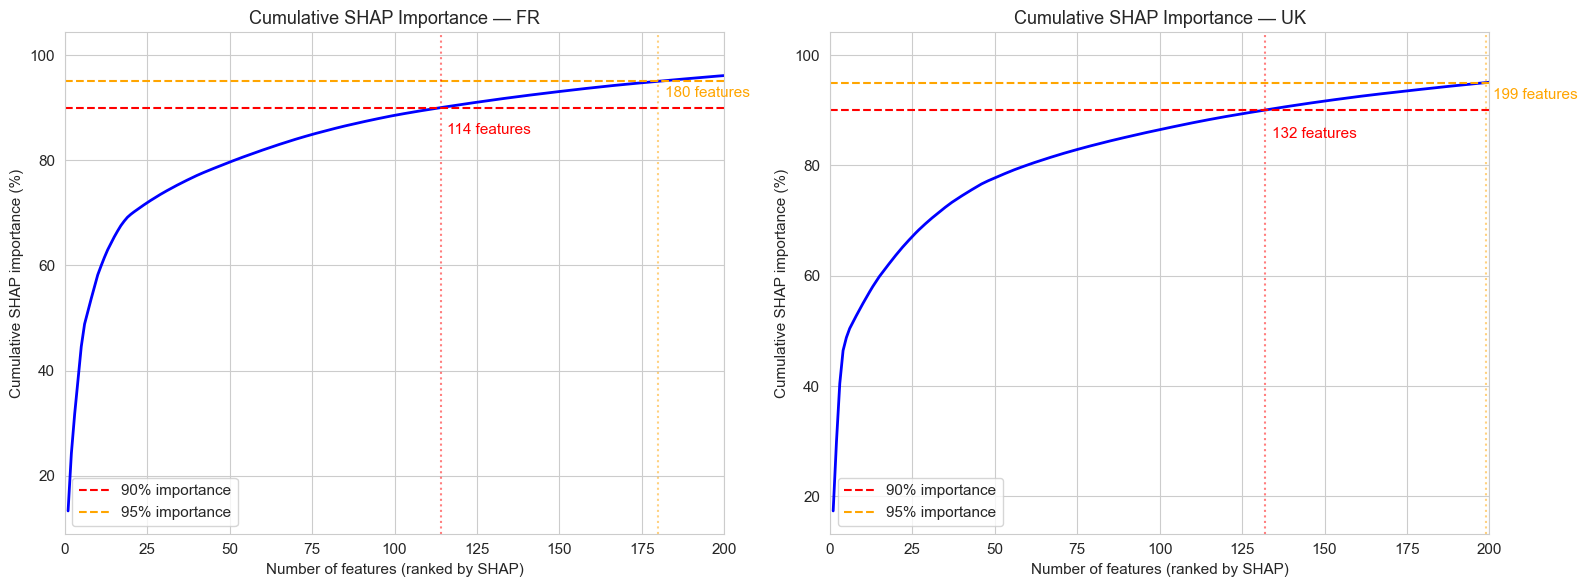

Au-delà du seuil 95%, ajouter des features n'apporte quasi rien


In [15]:
# Cumulative SHAP importance — diminishing returns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, imp, label in [(axes[0], shap_imp_fr, 'FR'), (axes[1], shap_imp_uk, 'UK')]:
    cumsum = imp.cumsum() / imp.sum() * 100
    ax.plot(range(1, len(cumsum)+1), cumsum.values, 'b-', linewidth=2)
    ax.axhline(90, color='red', linestyle='--', label='90% importance')
    ax.axhline(95, color='orange', linestyle='--', label='95% importance')
    
    # Find where we hit 90% and 95%
    n90 = (cumsum >= 90).idxmax()
    n95 = (cumsum >= 95).idxmax()
    idx90 = list(cumsum.index).index(n90) + 1
    idx95 = list(cumsum.index).index(n95) + 1
    
    ax.axvline(idx90, color='red', linestyle=':', alpha=0.5)
    ax.axvline(idx95, color='orange', linestyle=':', alpha=0.5)
    ax.text(idx90 + 2, 85, f'{idx90} features', color='red', fontsize=11)
    ax.text(idx95 + 2, 92, f'{idx95} features', color='orange', fontsize=11)
    
    ax.set_xlabel('Number of features (ranked by SHAP)')
    ax.set_ylabel('Cumulative SHAP importance (%)')
    ax.set_title(f'Cumulative SHAP Importance — {label}', fontsize=13)
    ax.legend()
    ax.set_xlim(0, 200)

plt.tight_layout()
plt.savefig('../outputs/shap_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print("Au-delà du seuil 95%, ajouter des features n'apporte quasi rien")

---
## 3. Boruta (si available)

Boruta crée des copies shadow (permutées aléatoirement) de toutes the features, entraîne un RandomForest, et teste statistiquement si chaque feature est significativement meilleure que sa copie shadow. C'est lent but robuste.

The results Boruta sont sauvegardés in `outputs/feature_selection_results.json` quand le process background termine.

In [16]:
# Load Boruta results if available
import json
from pathlib import Path

results_path = Path('../outputs/feature_selection_results.json')
if results_path.exists():
    with open(results_path) as f:
        all_results = json.load(f)
    
    for target in ['fr_spot', 'uk_spot']:
        r = all_results[target]
        print(f"\n{'='*60}")
        print(f"  {target.upper()} — Feature Selection Summary")
        print(f"{'='*60}")
        print(f"  Lasso:     {r['lasso_count'] if 'lasso_count' in r else len(r['lasso'])} features")
        print(f"  SHAP:      {r['shap_count'] if 'shap_count' in r else len(r['shap'])} features")
        print(f"  Boruta:    {len(r['boruta'])} features")
        print(f"  Consensus: {len(r['consensus'])} features (≥2 votes)")
        
        # Boruta-only features (not in SHAP top 150 or Lasso)
        boruta_only = set(r['boruta']) - set(r.get('shap', [])) - set(r.get('lasso', []))
        if boruta_only:
            print(f"\n  Boruta-only features ({len(boruta_only)}):")
            for f in sorted(boruta_only):
                print(f"    - {f}")
else:
    print("Boruta results not yet available. Run the background process first.")
    print("Check: outputs/feature_selection_results.json")

Boruta results not yet available. Run the background process first.
Check: outputs/feature_selection_results.json


In [17]:
# Final consensus visualization (3-method vote)
if results_path.exists():
    from collections import Counter
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, target, label in [(axes[0], 'fr_spot', 'FR'), (axes[1], 'uk_spot', 'UK')]:
        r = all_results[target]
        all_feats = r['lasso'] + r['shap'] + r['boruta']
        votes = Counter(all_feats)
        
        vote_dist = [sum(1 for v in votes.values() if v == i) for i in [1, 2, 3]]
        colors = ['#e74c3c', '#f39c12', '#2ecc71']
        labels_bar = ['1 method\n(low confidence)', '2 methods\n(consensus)', '3 methods\n(high confidence)']
        
        bars = ax.bar(labels_bar, vote_dist, color=colors)
        for bar, val in zip(bars, vote_dist):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', fontsize=13, fontweight='bold')
        
        ax.set_title(f'Feature Votes — {label}', fontsize=13)
        ax.set_ylabel('Number of features')
    
    plt.tight_layout()
    plt.savefig('../outputs/feature_votes_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Vert = validé par les 3 méthodes → ces features sont incontournables")

---
## 4. Conclusions

### Recommandation for the models :
- **CatBoost / LightGBM** : utiliser the features consensus (≥2 votes) → ~100-200 features
- **STGNN** : utiliser ~16 node features clés (spot_la, load, wind, solar, nuclear, gas, spark, residual, scarcity_ratio, calendar)
- **Neural SDE** : utiliser ~12 features état+contexte (spot_la, spark, residual, thermal, gas, wind_pen, nuclear_pct, scarcity, vol_ratio, jump_count)

### Features clés validées (top SHAP + Lasso):
1. **Spark spreads** (`de_spark_spread`, `fr_spark_spread`) — coût marginal du gaz, driver #1
2. **Prix voisins** (`ch_spot_la`, `at_spot_la`, `fr_spot_la`) — couplage SDAC
3. **Fondamentaux** (`thermal_need_x_gas`, `residual_load`, `scarcity_ratio`) — merit order
4. **Nos nouvelthe features** : `scarcity_ratio`, `security_margin`, `residual_zscore_14d`, `asinh_spot_la`, `residual_ramp_3h` — toutes in le top-30 SHAP